Read and display the image

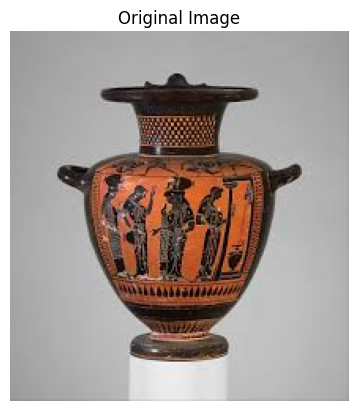

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Read the image
img = Image.open("/content/drive/MyDrive/AI and Machine Learning/images.jpeg")

# Convert image to numpy array
img_array = np.array(img)

# Display image
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

Display only the top left corner of 100x100 pixels.

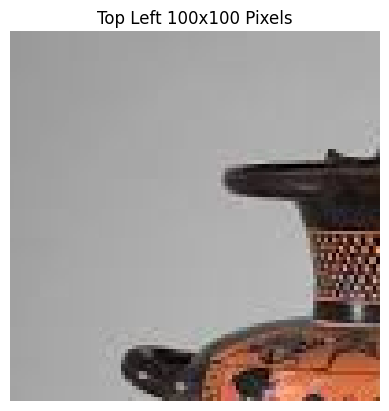

In [ ]:
# Extract top-left 100x100 pixels
top_left = img_array[0:100, 0:100]

# Display the cropped image
plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

Show the three color channels (R, G, B).

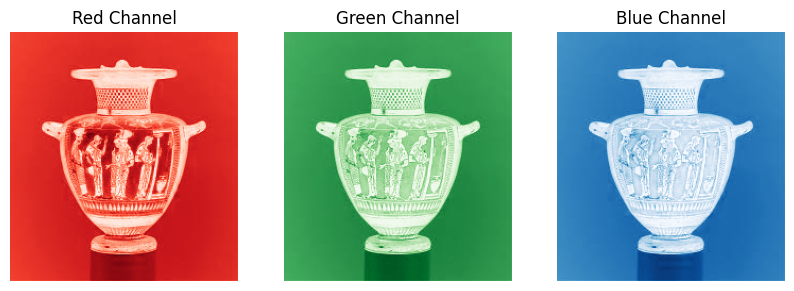

In [ ]:
# Separate color channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Display channels
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

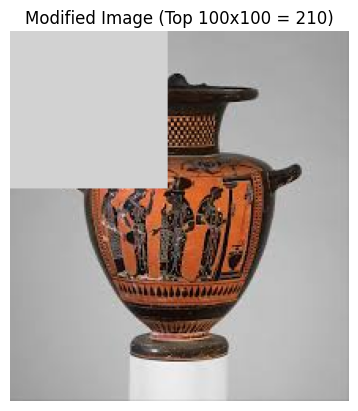

In [ ]:
# Copy original image
modified_img = img_array.copy()

# Modify top-left 100x100 pixels
modified_img[0:100, 0:100] = 210

# Display modified image
plt.imshow(modified_img)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

Exercise 2
1. Load and display a grayscale image.

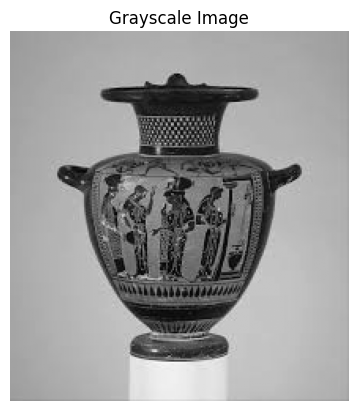

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image and convert to grayscale
img = Image.open("/content/drive/MyDrive/AI and Machine Learning/images.jpeg").convert("L")

# Convert to numpy array
img_array = np.array(img)

# Display grayscale image
plt.imshow(img_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

Extract and display the middle section of the image (150 pixels).

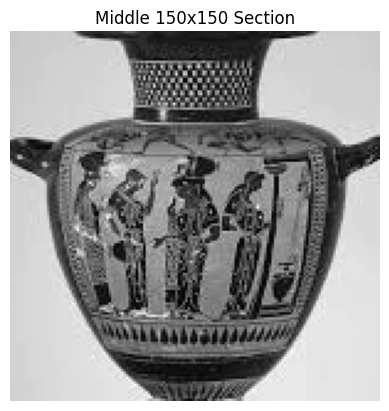

In [ ]:
# Get image dimensions
height, width = img_array.shape

# Find center
center_h = height // 2
center_w = width // 2

# Extract 150x150 center section
middle_section = img_array[center_h-75:center_h+75, center_w-75:center_w+75]

# Display cropped section
plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

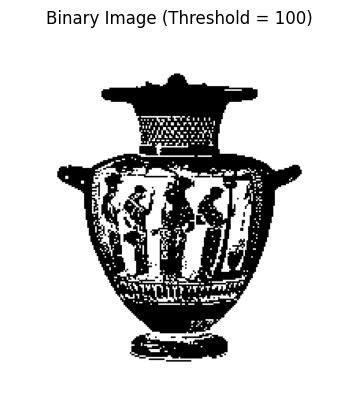

In [ ]:
# Create binary image
binary_img = img_array.copy()

binary_img[binary_img < 100] = 0
binary_img[binary_img >= 100] = 255

# Display binary image
plt.imshow(binary_img, cmap='gray')
plt.title("Binary Image (Threshold = 100)")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.

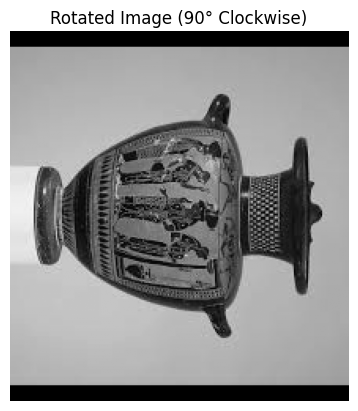

In [ ]:
# Rotate image 90 degrees clockwise
rotated_img = img.rotate(-90)

# Display rotated image
plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.

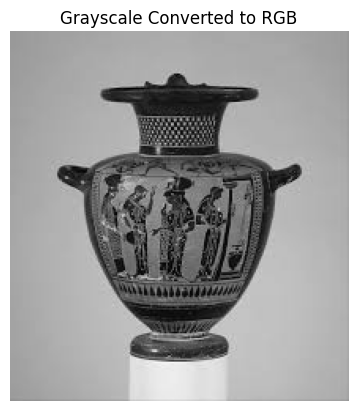

In [ ]:
# Convert grayscale to RGB
rgb_img = np.stack((img_array,)*3, axis=-1)

# Display RGB image
plt.imshow(rgb_img)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

Exercise 3
Load and Prepare Data:

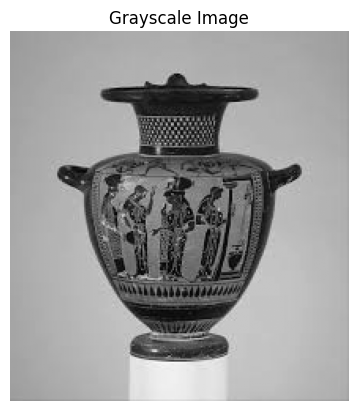

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = Image.open("/content/drive/MyDrive/AI and Machine Learning/images.jpeg")

# Convert to grayscale if image is colored
img_gray = img.convert("L")

# Convert to numpy array
data = np.array(img_gray)

# Display grayscale image
plt.imshow(data, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2. Eigen Decomposition and Identifying Principal Components:

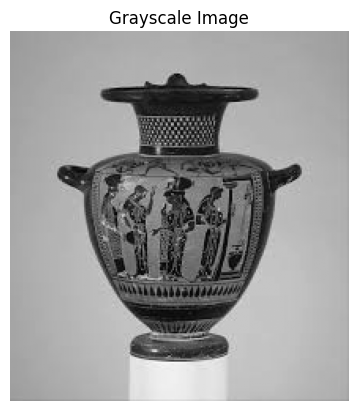

Covariance Matrix Shape: (235, 235)


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


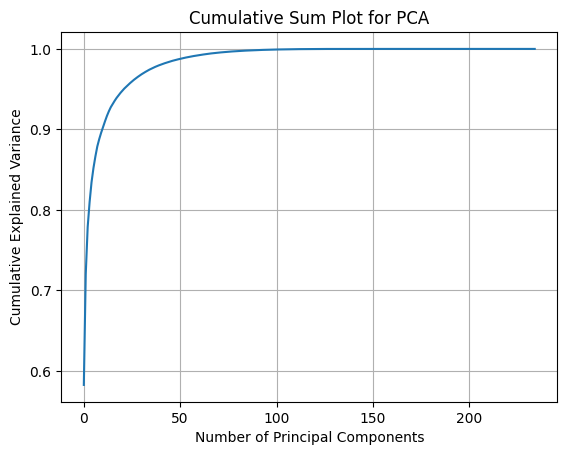

Top K Principal Components Shape: (235, 50)


In [ ]:
# Import libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Image and Convert to Grayscale
# -------------------------------
img = Image.open("/content/drive/MyDrive/AI and Machine Learning/images.jpeg")
gray_img = img.convert("L")

# Convert to numpy array
data = np.array(gray_img)

# Display grayscale image
plt.imshow(data, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# -------------------------------
# 2. Standardize the Data
# -------------------------------
mean = np.mean(data)
std = np.std(data)

standardized_data = (data - mean) / std

# -------------------------------
# 3. Calculate Covariance Matrix
# -------------------------------
cov_matrix = np.cov(standardized_data)

print("Covariance Matrix Shape:", cov_matrix.shape)

# -------------------------------
# 4. Eigen Decomposition
# -------------------------------
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# -------------------------------
# 5. Sort Eigenvalues (Descending)
# -------------------------------
sorted_index = np.argsort(eigen_values)[::-1]

sorted_eigenvalues = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

# -------------------------------
# 6. Explained Variance
# -------------------------------
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)

# -------------------------------
# 7. Cumulative Variance Plot
# -------------------------------
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Sum Plot for PCA")
plt.grid(True)
plt.show()

# -------------------------------
# 8. Select Top K Principal Components
# -------------------------------
k = 50
principal_components = sorted_eigenvectors[:, :k]

print("Top K Principal Components Shape:", principal_components.shape)

Reconstruction and Experiment:

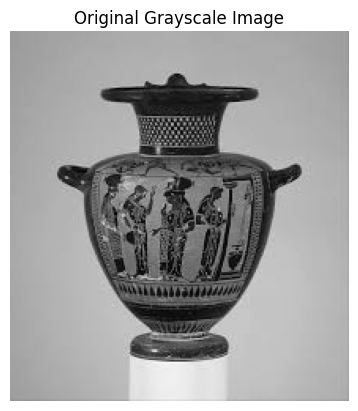

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


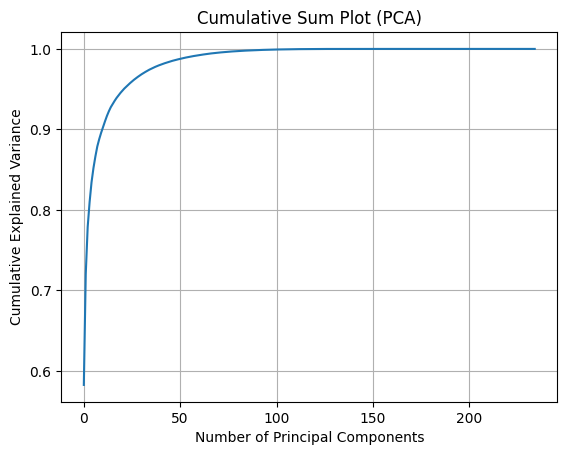

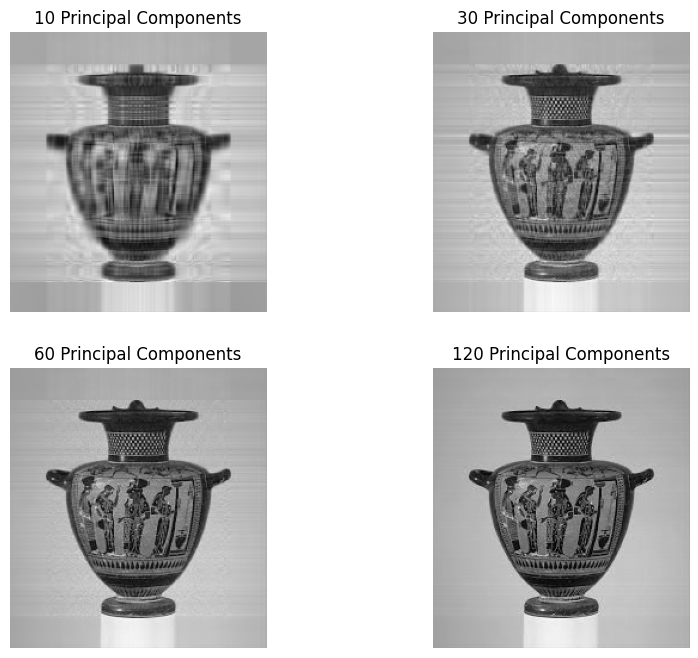

In [ ]:
# Import libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Image and Convert to Grayscale
# -------------------------------
img = Image.open("/content/drive/MyDrive/AI and Machine Learning/images.jpeg")
gray_img = img.convert("L")

data = np.array(gray_img)

# Display original grayscale image
plt.imshow(data, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

# -------------------------------
# 2. Standardize the Data
# -------------------------------
mean = np.mean(data)
std = np.std(data)

standardized_data = (data - mean) / std

# -------------------------------
# 3. Covariance Matrix
# -------------------------------
cov_matrix = np.cov(standardized_data)

# -------------------------------
# 4. Eigen Decomposition
# -------------------------------
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# -------------------------------
# 5. Sort Eigenvalues and Eigenvectors
# -------------------------------
sorted_index = np.argsort(eigen_values)[::-1]

sorted_eigenvalues = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

# -------------------------------
# 6. Explained Variance
# -------------------------------
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

# -------------------------------
# 7. Plot Cumulative Variance
# -------------------------------
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Sum Plot (PCA)")
plt.grid(True)
plt.show()

# -------------------------------
# 8. Reconstruction Experiments
# -------------------------------
pcs_list = [10, 30, 60, 120]

plt.figure(figsize=(10,8))

for i, k in enumerate(pcs_list):

    # Select top k eigenvectors
    pcs = sorted_eigenvectors[:, :k]

    # Reduce dimension
    reduced_data = np.dot(pcs.T, standardized_data)

    # Reconstruct image
    reconstructed = np.dot(pcs, reduced_data)

    # Convert back to original scale
    reconstructed = (reconstructed * std + mean).real

    # Display result
    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"{k} Principal Components")
    plt.axis("off")

plt.show()